# Designing a Multi-Step Data Pipeline

A **Data Pipeline** is a series of steps that takes raw, messy data, filters it, transforms it, and outputs clean insights or beautiful charts.
In software development (like in Angular), you often fetch raw JSON from an API, pass it through RxJS pipes, map over the fields, filter out invalid entries, and display the final values in a UI component.

In Python Data Science, we do the exact same thing using NumPy, Pandas, and Matplotlib:
1. **Ingest**: Read raw files (CSVs) into memory.
2. **Clean**: Find missing values (`NaN`s), remove duplicates, and fix wrong data types.
3. **Transform**: Calculate new metrics using vectorization and broadcasting.
4. **Aggregate**: Summarize categories (e.g., averages, sums).
5. **Visualize**: Render a professional dashboard that tells a story.

Building structured pipelines prevents code duplication and makes your data processing robust and repeatable!

### Simple Explanation with an Everyday Analogy
Imagine a **Water Filtration Plant**:
* **Step 1 (Ingest)**: Dirty water is pumped from a local river into a large tank.
* **Step 2 (Clean)**: Grates and screens remove leaves, mud, and debris. Any harmful chemicals are neutralized (just like replacing `NaN` with a safe average!).
* **Step 3 (Transform)**: Fluoride and minerals are added to the entire water stream at once (just like vectorizing a salary bonus to a whole array).
* **Step 4 (Deliver/Visualize)**: The sparkling clean water is bottled, labeled, and sent to supermarkets for people to enjoy.

If you don't do these steps in a strict, structured order, your final product will be contaminated!

### Code Example: A Tiny Pipeline
Let's see a small, runnable example of a 3-step pipeline: Ingest ➡️ Clean ➡️ Transform.


In [3]:
import numpy as np
import pandas as pd

# Step 1: Ingest (Load raw messy dictionary data)
raw_data = {
    'Dev_ID': [501, 502, 503, 504],
    'Hours': [8.0, np.nan, 7.5, 9.0], # 502 has missing hours
    'Base_Pay': [4000, 4500, 3800, 5200]
}
df = pd.DataFrame(raw_data)
print("Step 1 (Raw Data):\n", df)

# Step 2: Clean (Replace NaN hours with the median hours)
median_hours = df['Hours'].median()
df['Hours'] = df['Hours'].fillna(median_hours)
print("\nStep 2 (Cleaned Data):\n", df)

# Step 3: Transform (Calculate Hourly Rate using vectorization)
# Hourly Rate = Base Pay / (Hours * 20 working days)
df['Hourly_Rate'] = df['Base_Pay'] / (df['Hours'] * 20)
print("\nStep 3 (Transformed Data):\n", df)

Step 1 (Raw Data):
    Dev_ID  Hours  Base_Pay
0     501    8.0      4000
1     502    NaN      4500
2     503    7.5      3800
3     504    9.0      5200

Step 2 (Cleaned Data):
    Dev_ID  Hours  Base_Pay
0     501    8.0      4000
1     502    8.0      4500
2     503    7.5      3800
3     504    9.0      5200

Step 3 (Transformed Data):
    Dev_ID  Hours  Base_Pay  Hourly_Rate
0     501    8.0      4000    25.000000
1     502    8.0      4500    28.125000
2     503    7.5      3800    25.333333
3     504    9.0      5200    28.888889


# The Grand Capstone - Web Developer Tech Stack Analytics

Now, let's build the ultimate project. Imagine you are a Senior Engineering Manager. You want to analyze survey data from **10 web developers** in your company.
The raw file contains:
* `Developer_ID`
* `Daily_Coding_Hours`
* `Bugs_Solved`
* `TypeScript_Score` (0 to 10 scale)
* `Current_Salary_USD`

We will write a single Python script that cleans this dataset, filters out outliers, performs matrix-level math, and outputs a **beautiful, 4-panel visual dashboard** showing our engineering metrics!

### Simple Explanation with an Everyday Analogy
Imagine you are building a **reactive dashboard widget** in Angular using a chart library.
To feed data into the chart, you must:
1. Extract the columns.
2. Bind the values to the chart's X and Y inputs.
3. Apply color-coding depending on developer performance.
4. Render legend labels so stakeholders can understand who is who.

We will do this entire workflow programmatically using Python scripts, saving our results as highly optimized vector charts.

### Code Example: Full Pipeline & Dashboard Generation
Here is our full capstone pipeline script. Read the comments carefully to see how every module we studied fits together!



--- PIPELINE STATS ---
Average Efficiency: 2.04 bugs/hour
Max Salary After Raise: $132,000.00
TypeScript Experts (Score >= 8): 5

Dashboard generated successfully!


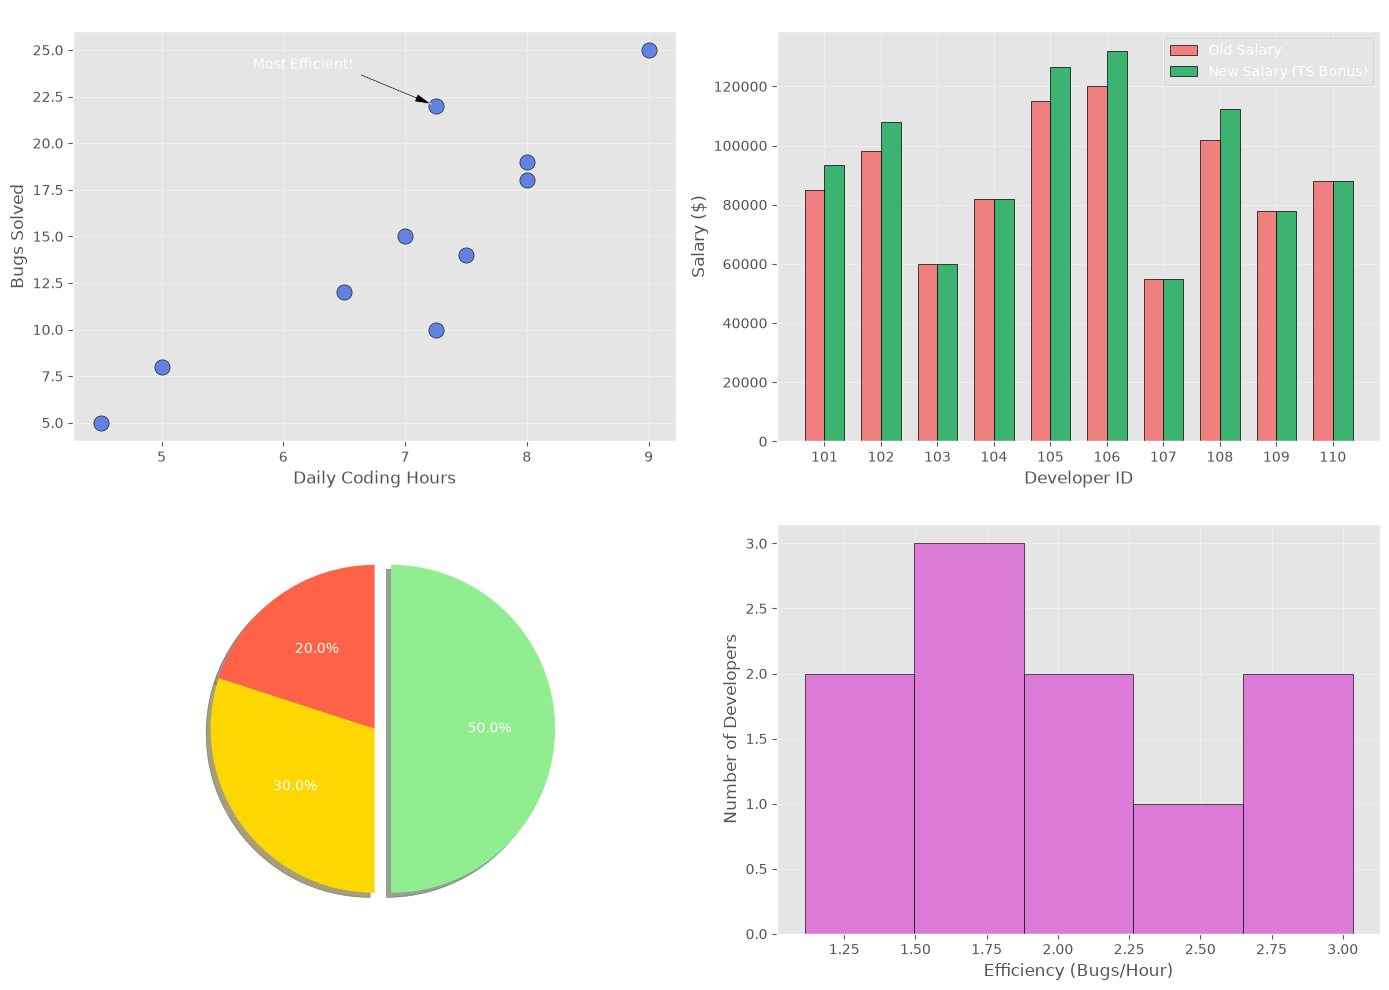

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set a professional plotting style
plt.style.use('ggplot')

# ==========================================
# STEP 1: INGEST (Generate mock developer dataset)
# ==========================================
data = {
    'Dev_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Coding_Hours': [6.5, 8.0, 5.0, 7.5, np.nan, 9.0, 4.5, 8.0, 7.0, np.nan], # contains NaNs
    'Bugs_Solved': [12, 18, 8, 14, 22, 25, 5, 19, 15, 10],
    'TS_Score': [8, 9, 4, 7, 10, 8, 3, 9, 5, 7],
    'Salary_USD': [85000, 98000, 60000, 82000, 115000, 120000, 55000, 102000, 78000, 88000]
}
df = pd.DataFrame(data)

# ==========================================
# STEP 2: CLEAN (Replace NaNs with median coding hours)
# ==========================================
median_hours = df['Coding_Hours'].median()
df['Coding_Hours'] = df['Coding_Hours'].fillna(median_hours)

# Convert our Pandas DataFrame columns to fast NumPy arrays
dev_ids = df['Dev_ID'].to_numpy()
hours = df['Coding_Hours'].to_numpy()
bugs = df['Bugs_Solved'].to_numpy()
ts_scores = df['TS_Score'].to_numpy()
salaries = df['Salary_USD'].to_numpy()

# ==========================================
# STEP 3: TRANSFORM (Vectorized Math & Broadcasting)
# ==========================================
# 1. Calculate efficiency: Bugs Solved per Coding Hour
efficiency = bugs / hours

# 2. Give a 10% raise to high-skill TypeScript developers (TS_Score >= 8)
# We use np.where(condition, value_if_true, value_if_false)
new_salaries = np.where(ts_scores >= 8, salaries * 1.10, salaries)

# ==========================================
# STEP 4: AGGREGATE
# ==========================================
avg_efficiency = np.mean(efficiency)
max_salary = np.max(new_salaries)
ts_experts_count = np.sum(ts_scores >= 8)

print("--- PIPELINE STATS ---")
print(f"Average Efficiency: {avg_efficiency:.2f} bugs/hour")
print(f"Max Salary After Raise: ${max_salary:,.2f}")
print(f"TypeScript Experts (Score >= 8): {ts_experts_count}")

# ==========================================
# STEP 5: VISUALIZE (2x2 Dashboard)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1 (Top-Left): Scatter Plot of Hours vs. Bugs
axes[0, 0].scatter(hours, bugs, color='royalblue', s=120, alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Coding Hours vs. Bugs Solved', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Daily Coding Hours')
axes[0, 0].set_ylabel('Bugs Solved')

# Annotate the most efficient developer
max_eff_idx = np.argmax(efficiency)
axes[0, 0].annotate('Most Efficient!',
                    xy=(hours[max_eff_idx], bugs[max_eff_idx]),
                    xytext=(hours[max_eff_idx] - 1.5, bugs[max_eff_idx] + 2),
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Subplot 2 (Top-Right): Bar Chart Comparing Old vs. New Salary
x_indices = np.arange(len(dev_ids))
width = 0.35

axes[0, 1].bar(x_indices - width/2, salaries, width, label='Old Salary', color='lightcoral', edgecolor='black')
axes[0, 1].bar(x_indices + width/2, new_salaries, width, label='New Salary (TS Bonus)', color='mediumseagreen', edgecolor='black')
axes[0, 1].set_title('Salary Adjustments (10% TS Raise)', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_indices)
axes[0, 1].set_xticklabels(dev_ids)
axes[0, 1].set_xlabel('Developer ID')
axes[0, 1].set_ylabel('Salary ($)')
axes[0, 1].legend()

# Subplot 3 (Bottom-Left): Pie Chart of TypeScript Scores Distribution
# Group scores into: Low (<5), Medium (5-7), High (>=8)
low = np.sum(ts_scores < 5)
med = np.sum((ts_scores >= 5) & (ts_scores < 8))
high = np.sum(ts_scores >= 8)

categories = ['Low (<5)', 'Medium (5-7)', 'High (>=8)']
counts = [low, med, high]
explode = [0, 0, 0.1] # Highlight high scorers

axes[1, 0].pie(counts, labels=categories, autopct='%1.1f%%', startangle=90,
               explode=explode, colors=['tomato', 'gold', 'lightgreen'], shadow=True)
axes[1, 0].set_title('TypeScript Skill Distribution', fontsize=12, fontweight='bold')

# Subplot 4 (Bottom-Right): Histogram of Developer Efficiency
axes[1, 1].hist(efficiency, bins=5, color='orchid', edgecolor='black', alpha=0.9)
axes[1, 1].set_title('Developer Efficiency Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Efficiency (Bugs/Hour)')
axes[1, 1].set_ylabel('Number of Developers')

plt.tight_layout()
# Instead of plt.show(), save the dashboard!
plt.savefig('developer_dashboard.png', dpi=150, bbox_inches='tight')
print("\nDashboard generated successfully!")

# Common Pitfalls in Large-Scale Data Visualizations

When you move from small tutorials to working with massive datasets (like millions of client-side error logs or production metrics), your code can easily break or slow down.
Here are the three golden rules to keep your code fast and your memory clean:

1. **Avoid Explicit Loops for Math**:
   Never write a `for` loop to filter or update elements in an array. Always use Boolean Indexing, Vectorization, or `np.where()`.
2. **Be Careful with Views vs. Copies**:
   If you slice an array (`slice = arr[0:5]`) and modify it, the original array changes. If you wanted to preserve the original, always write `slice = arr[0:5].copy()`.
3. **Prevent Memory Leaks in Matplotlib**:
   When generating many charts inside a script or a loop, Matplotlib keeps figures in memory. This will eventually crash your server (Out of Memory error). Always call `plt.close()` after saving a chart to release memory!

### Simple Explanation with an Everyday Analogy
Imagine you are a painter with 100 canvases.
* **The Copy Trap**: If you use a magical mirror (a View) to paint, whatever you draw on the mirror actually appears on the original canvas. If you wanted to practice on a separate paper, you must physically buy a new canvas (a Copy).
* **The Memory Trap**: If you finish a painting and keep it on the easel, eventually your room will be completely full, and you won't be able to walk. You must put the finished canvas away in storage (call `plt.close()`) to free up space!

### Code Example: Safely Generating Multiple Charts


Saved wave_1.png


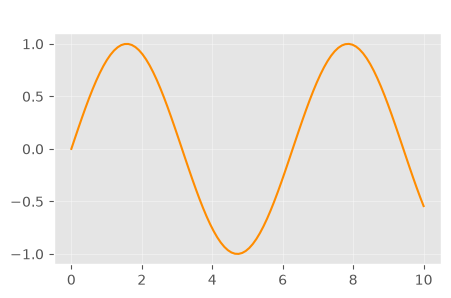

Saved wave_2.png


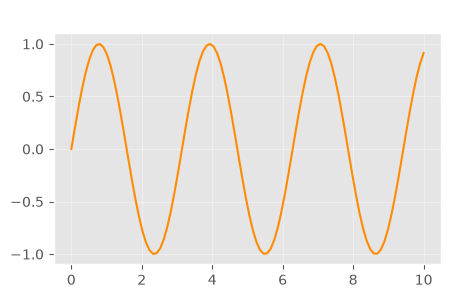

Saved wave_3.png


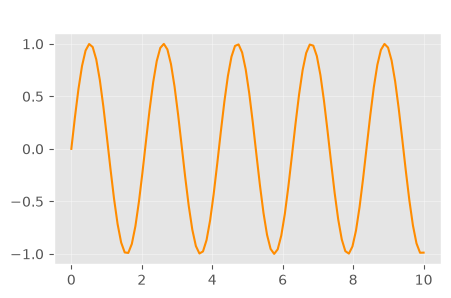

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Let's say we need to generate 3 separate charts in a loop
for i in range(1, 4):
    # 1. Create figure
    fig, ax = plt.subplots(figsize=(5, 3))

    # 2. Draw plot
    x = np.linspace(0, 10, 100)
    ax.plot(x, np.sin(x * i), color='darkorange')
    ax.set_title(f"Wave Pattern {i}")

    # 3. Save plot
    filename = f"wave_{i}.png"
    plt.savefig(filename, dpi=100)
    print(f"Saved {filename}")
    plt.show()

    # 4. CRUCIAL: Close the figure to free up RAM!
    plt.close(fig)

## Common Mistakes Beginners Make
1. **Not closing Matplotlib figures in loops**: This creates thousands of active figure objects in memory and causes server crashes.
2. **Confusing Python `and`/`or` with NumPy Bitwise `&`/`|`**: When writing compound boolean masks like `(scores > 50) & (scores < 80)`, writing `and` instead of `&` will raise a `ValueError`.
3. **Modifying a Slice instead of a Copy**: Forgetting that slicing returns a memory view. If you change a slice, you mutate the source database.

### Exercise 1 (Easy)
Write a Python statement that takes our Capstone array of `bugs` (`[12, 18, 8, 14, 22, 25, 5, 19, 15, 10]`) and uses **Boolean Indexing** to extract only the developers who solved **more than 15 bugs**.

In [9]:
import numpy as np
bugs = np.array([12, 18, 8, 14, 22, 25, 5, 19, 15, 10])

# Filter out elements > 15
high_bugs = bugs[bugs > 15]
print("High Bugs:", high_bugs)

High Bugs: [18 22 25 19]


*Explanation:* The comparison `bugs > 15` creates a boolean mask `[False, True, False, False, True, True, False, True, False, False]`. We pass this mask back into the brackets `bugs[...]` to extract the elements corresponding to `True`.


### Exercise 2 (Medium)
Take our Capstone array of `salaries`:
`salaries = np.array([85000, 98000, 60000, 82000, 115000, 120000, 55000, 102000, 78000, 88000])`
Apply a **15% bonus** to all developers who solved **more than 15 bugs**, and keep all other salaries the same. Use `np.where()`.


In [10]:
import numpy as np
bugs = np.array([12, 18, 8, 14, 22, 25, 5, 19, 15, 10])
salaries = np.array([85000, 98000, 60000, 82000, 115000, 120000, 55000, 102000, 78000, 88000])

# Apply 15% raise if bugs > 15, else keep salary original
bonus_salaries = np.where(bugs > 15, salaries * 1.15, salaries)
print("Adjusted Salaries:", bonus_salaries)

Adjusted Salaries: [ 85000. 112700.  60000.  82000. 132250. 138000.  55000. 117300.  78000.
  88000.]


*Explanation:* `np.where` checks the condition element-by-element. If a developer has solved more than 15 bugs, it multiplies their salary by `1.15` (a 15% bonus). Otherwise, it retains the original salary value.


### Exercise 3 (Hard)
Create a 3D coordinate system representing a developer's metrics:
* X-axis: Daily Coding Hours
* Y-axis: Bugs Solved
* Z-axis: TypeScript Score
Using the data from Module 35, write a Python script that plots these 10 developers as a **3D Scatter Plot** with customized titles and labels.


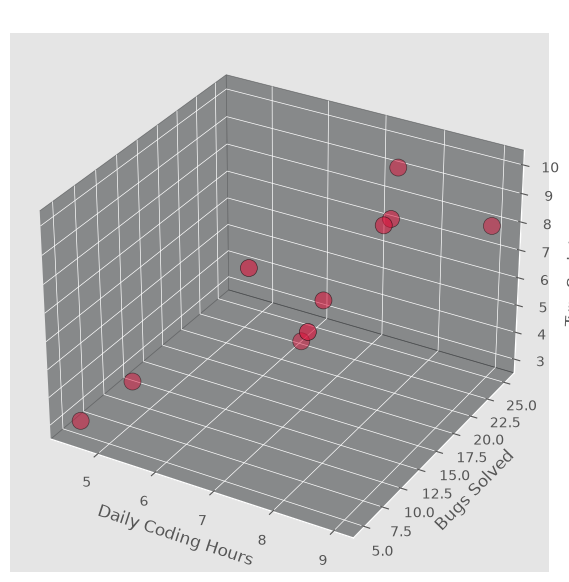

3D Scatter plot saved successfully!


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Retrieve raw columns
hours = np.array([6.5, 8.0, 5.0, 7.5, 7.75, 9.0, 4.5, 8.0, 7.0, 7.75])
bugs = np.array([12, 18, 8, 14, 22, 25, 5, 19, 15, 10])
ts_scores = np.array([8, 9, 4, 7, 10, 8, 3, 9, 5, 7])

# Create 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Draw 3D scatter plot
ax.scatter(hours, bugs, ts_scores, color='crimson', s=150, edgecolor='black', alpha=0.8)

# Set labels
ax.set_title('3D Developer Metrics Landscape', fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Coding Hours')
ax.set_ylabel('Bugs Solved')
ax.set_zlabel('TypeScript Score')

plt.savefig('dev_metrics_3d.png', dpi=150)
plt.show()
plt.close(fig)
print("3D Scatter plot saved successfully!")

*Explanation:* We import `matplotlib.pyplot` and use `projection='3d'` to initialize our 3D space. We call `ax.scatter()` passing our three coordinate arrays (`hours`, `bugs`, `ts_scores`) to plot them as points in 3D space.
